UNZIPPING THE ZIP FILE AND EXTRACTING THE DATASET

In [12]:
import zipfile
import os

# Path to the ZIP file
zip_path = "Birds.zip"

# Extract to a specific folder
extract_path = "Bird Identification"

# Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


INSTALLING TENSORFLOW

In [13]:
!pip install tensorflow

IMPORTING NECESSARY LIBRARIES

In [14]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

LOADING THE DATASET

In [15]:
# generators to reduce the load on RAM
train_ds=keras.utils.image_dataset_from_directory(
    directory='Bird Identification/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='Bird Identification/valid',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

test_ds=keras.utils.image_dataset_from_directory(
    directory='Bird Identification/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 3208 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.


VISUALIZE A FEW RANDOM IMAGES

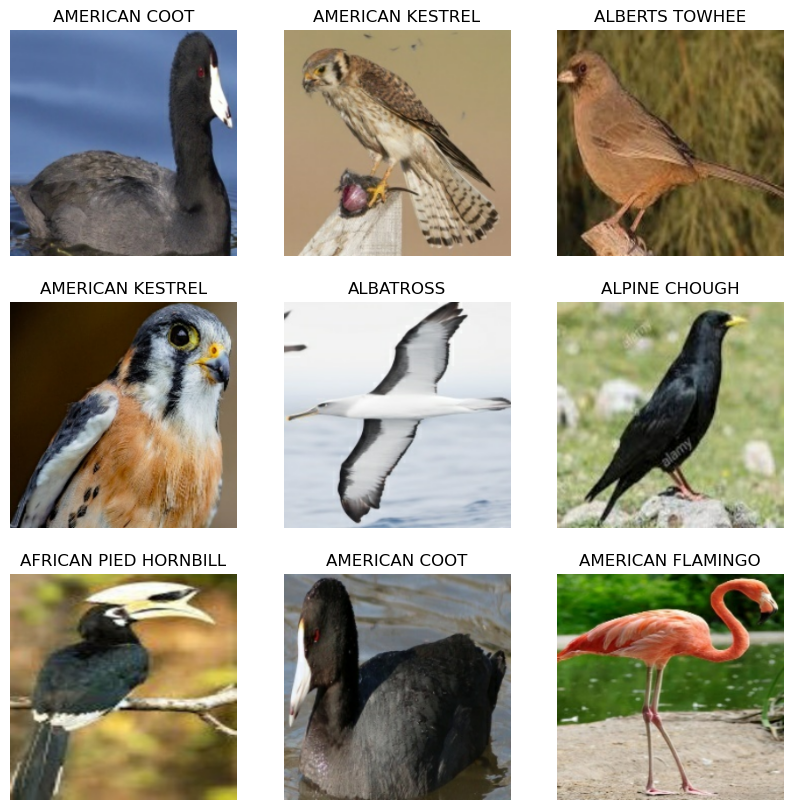

'\ntrain_ds.class_names → Retrieves the names of bird species inferred from the folder structure.\n\nDefine the show_random_images Function:\n\ndef show_random_images(dataset, num_images=9):\n    plt.figure(figsize=(10, 10))  # Create a 10x10 inch figure\n\nCreates a new figure for displaying images.\n\nExtract One Batch of Images:\n\nfor images, labels in dataset.take(1):  \ndataset.take(1) → Takes only one batch of images (default batch size is 32).\nimages, labels → Contains:\nimages → Image tensors.\nlabels → Corresponding class indices (e.g., 0, 1, 2, etc.).\n\nDisplay Images in a 3x3 Grid:\n\nfor i in range(num_images):\n    ax = plt.subplot(3, 3, i + 1)  # Create a 3x3 grid\n    plt.imshow(images[i].numpy().astype("uint8"))  # Convert image tensor to NumPy format\n    plt.title(class_names[labels[i].numpy()])  # Get the class name\n    plt.axis("off")  # Hide axes\nplt.subplot(3, 3, i + 1) → Creates a subplot (3 rows, 3 columns).\nimages[i].numpy().astype("uint8") → Converts Ten

In [16]:
import matplotlib.pyplot as plt

# Get class names from dataset
class_names = train_ds.class_names  

# Function to display random images
def show_random_images(dataset, num_images=9):
    plt.figure(figsize=(10, 10))

    # Take one batch from the dataset
    for images, labels in dataset.take(1):  
        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))  # Convert tensor to image
            plt.title(class_names[labels[i].numpy()])  # Show bird species name
            plt.axis("off")  # Hide axes
    
    plt.show()

# Show random images from the training dataset
show_random_images(train_ds)

'''
train_ds.class_names → Retrieves the names of bird species inferred from the folder structure.

Define the show_random_images Function:

def show_random_images(dataset, num_images=9):
    plt.figure(figsize=(10, 10))  # Create a 10x10 inch figure

Creates a new figure for displaying images.

Extract One Batch of Images:

for images, labels in dataset.take(1):  
dataset.take(1) → Takes only one batch of images (default batch size is 32).
images, labels → Contains:
images → Image tensors.
labels → Corresponding class indices (e.g., 0, 1, 2, etc.).

Display Images in a 3x3 Grid:

for i in range(num_images):
    ax = plt.subplot(3, 3, i + 1)  # Create a 3x3 grid
    plt.imshow(images[i].numpy().astype("uint8"))  # Convert image tensor to NumPy format
    plt.title(class_names[labels[i].numpy()])  # Get the class name
    plt.axis("off")  # Hide axes
plt.subplot(3, 3, i + 1) → Creates a subplot (3 rows, 3 columns).
images[i].numpy().astype("uint8") → Converts TensorFlow tensor into a NumPy array for visualization.
plt.title(class_names[labels[i].numpy()]) → Displays the bird species name above the image.
plt.axis("off") → Hides the axes.

Display the Images:

plt.show()

Displays the final grid of images.

Call the Function to Show Random Images:

show_random_images(train_ds)

Calls the function to display random images from train_ds.'''

CHECKING CLASS IMBALANCE


Train Set Class Distribution:
ABBOTTS BABBLER: 166 images
ABBOTTS BOOBY: 180 images
ABYSSINIAN GROUND HORNBILL: 179 images
AFRICAN CROWNED CRANE: 137 images
AFRICAN EMERALD CUCKOO: 154 images
AFRICAN FIREFINCH: 137 images
AFRICAN OYSTER CATCHER: 155 images
AFRICAN PIED HORNBILL: 187 images
AFRICAN PYGMY GOOSE: 179 images
ALBATROSS: 133 images
ALBERTS TOWHEE: 161 images
ALEXANDRINE PARAKEET: 165 images
ALPINE CHOUGH: 166 images
ALTAMIRA YELLOWTHROAT: 150 images
AMERICAN AVOCET: 179 images
AMERICAN BITTERN: 170 images
AMERICAN COOT: 158 images
AMERICAN FLAMINGO: 164 images
AMERICAN GOLDFINCH: 133 images
AMERICAN KESTREL: 155 images

Validation Set Class Distribution:
ABBOTTS BABBLER: 5 images
ABBOTTS BOOBY: 5 images
ABYSSINIAN GROUND HORNBILL: 5 images
AFRICAN CROWNED CRANE: 5 images
AFRICAN EMERALD CUCKOO: 5 images
AFRICAN FIREFINCH: 5 images
AFRICAN OYSTER CATCHER: 5 images
AFRICAN PIED HORNBILL: 5 images
AFRICAN PYGMY GOOSE: 5 images
ALBATROSS: 5 images
ALBERTS TOWHEE: 5 images
ALEXA

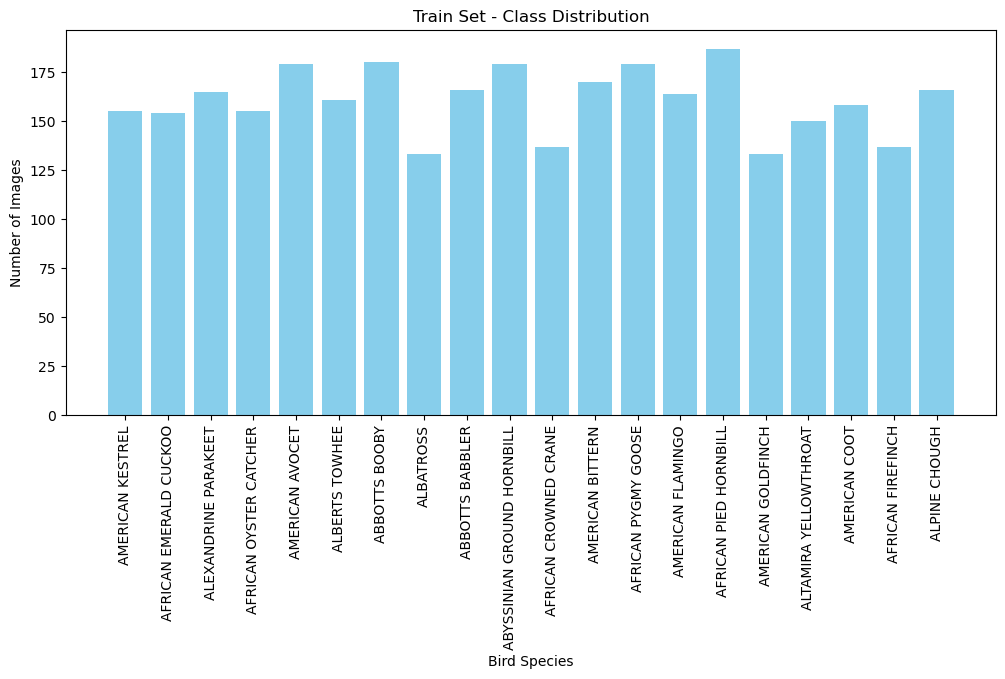

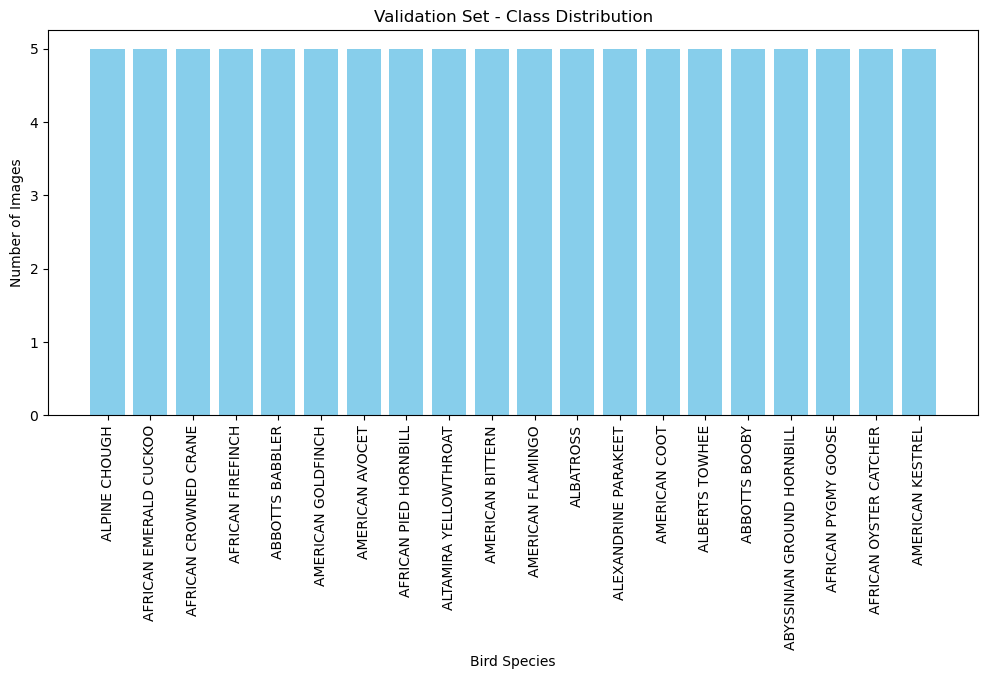

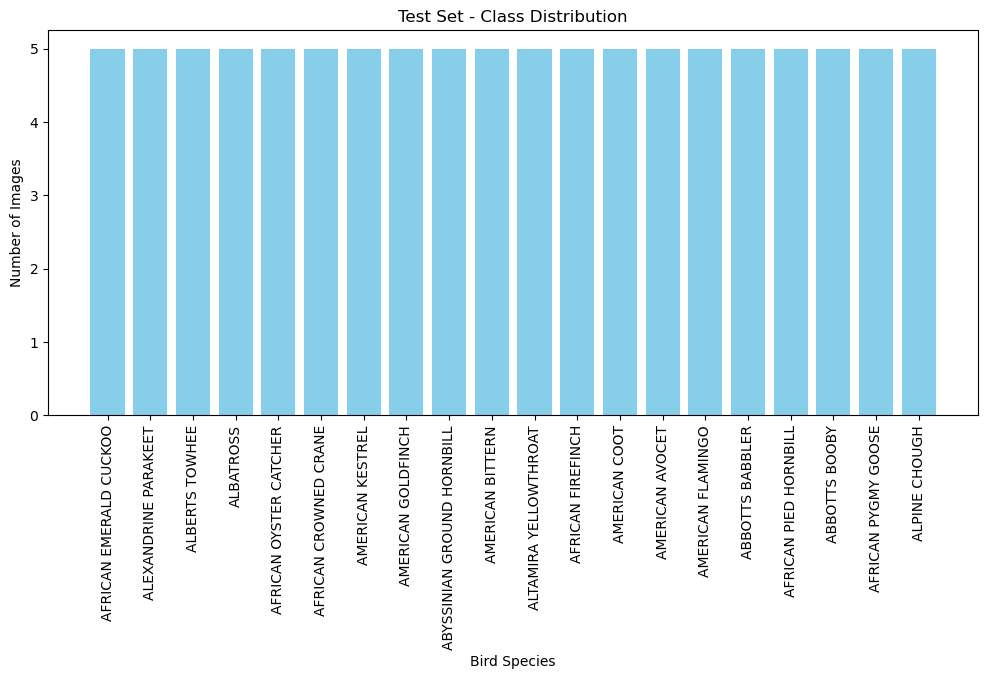

'Calls plot_class_distribution() to visualize class imbalance for each dataset.'

In [17]:
import collections

''' tensorflow as tf → Used for handling image datasets.
matplotlib.pyplot as plt → Used for visualizing class distributions.
collections → Provides Counter, which is used to count occurrences of each class label.'''

# Get class names from dataset
class_names = train_ds.class_names  # The class names inferred from directory structure

'''train_ds.class_names returns a list of class names (bird species).
These names are inferred from the folder structure inside the dataset.'''

# Function to count class distribution
def get_class_distribution(dataset, dataset_name):
    class_counts = collections.Counter()

    for _, labels in dataset:  # Iterate through batches
        class_counts.update(labels.numpy())  # Convert labels to NumPy and count occurrences

    print(f"\n{dataset_name} Set Class Distribution:")
    for i, count in sorted(class_counts.items()):
        print(f"{class_names[i]}: {count} images")

    return class_counts

'''Initializes a Counter to store image counts per class.
Iterates over batches of the dataset.
Extracts the labels, converts them to a NumPy array, and updates the counter.
Prints the class distribution (i.e., the number of images per class).
Returns the class counts as a dictionary {class_index: count}.'''

# Get class distributions
train_counts = get_class_distribution(train_ds, "Train")
val_counts = get_class_distribution(validation_ds, "Validation")
test_counts = get_class_distribution(test_ds, "Test")

'''Calls get_class_distribution() on the train, validation, and test datasets.
Stores the results in train_counts, val_counts, and test_counts.'''

# Function to plot class distribution
def plot_class_distribution(class_counts, dataset_name):
    species = [class_names[i] for i in class_counts.keys()]
    counts = list(class_counts.values())

    plt.figure(figsize=(12, 5))
    plt.bar(species, counts, color='skyblue')
    plt.xticks(rotation=90)
    plt.xlabel("Bird Species")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} Set - Class Distribution")
    plt.show()
   

'''Extracts class names corresponding to the class indices.
Extracts the count of images per class.
Uses plt.bar() to create a bar chart.
Rotates x-axis labels for readability.
Adds labels and title to the plot.'''

# Plot distributions
plot_class_distribution(train_counts, "Train")
plot_class_distribution(val_counts, "Validation")
plot_class_distribution(test_counts, "Test")

'''Calls plot_class_distribution() to visualize class imbalance for each dataset.'''

The diagram implies that class imbalance is not there in the dataset.

DATA AUGMENTATION

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation parameters
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=30,           # Rotate images randomly within 30 degrees
    width_shift_range=0.2,       # Shift images horizontally by 20% of width
    height_shift_range=0.2,      # Shift images vertically by 20% of height
    shear_range=0.2,             # Apply shear transformation up to 20%
    zoom_range=0.2,              # Zoom in/out up to 20%
    horizontal_flip=True,        # Randomly flip images horizontally
    fill_mode='nearest'          # Fill missing pixels after transformation
)

# Load augmented images from training dataset
train_generator = train_datagen.flow_from_directory(
    'Bird Identification/train',               # Path to training dataset
    target_size=(256, 256),      # Resize images to 256x256 pixels
    batch_size=32,               # Number of images per batch
    class_mode='sparse'     # Multi-class classification
)

Found 3208 images belonging to 20 classes.


           Hyperparameter	                                  Explanation
           rescale=1./255	     Scales pixel values from [0, 255] to [0, 1] for normalization, which stabilizes training.
         rotation_range=30	     Rotates images randomly within a range of ±30 degrees, preventing models from learning rotation bias.
       width_shift_range=0.2	 Shifts the image horizontally by up to 20% of its width, helping the model learn position invariance.
      height_shift_range=0.2	 Shifts the image vertically by up to 20% of its height, making the model robust to object displacement.
          shear_range=0.2	     Applies shear transformation, which slants the image to simulate different perspectives.
           zoom_range=0.2	     Randomly zooms in or out by up to 20%, improving the model’s ability to recognize objects at various distances.
       horizontal_flip=True	     Randomly flips images left to right, helping the model generalize better for symmetrical objects like birds.
        fill_mode='nearest'	     Fills in missing pixels after transformations using nearest neighbor interpolation, ensuring smooth transitions.

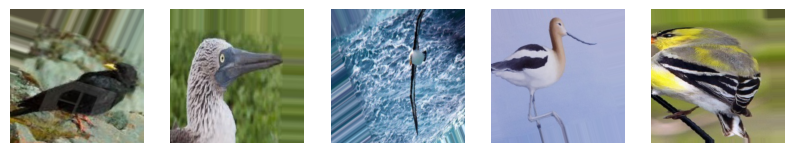

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Load a batch of images
batch = next(train_generator)
images, labels = batch

# Plot augmented images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

PREPROCESSING (NORMALIZATION) AND PREFETCHING

In [20]:
from tensorflow.keras import layers



# Function to preprocess images (Normalize pixel values)
def preprocess(image, label):
    image = tf.cast(image/255. , tf.float32)  # Normalize to [0,1]
    return image, label



# Apply preprocess to all datasets
AUTOTUNE = tf.data.AUTOTUNE  # Optimize data pipeline



train_ds = train_ds.map(preprocess).prefetch(AUTOTUNE)  # Normalize & prefetch

validation_ds = validation_ds.map(preprocess).prefetch(AUTOTUNE)  # Normalize & prefetch

test_ds = test_ds.map(preprocess).prefetch(AUTOTUNE)  # Normalize & prefetch

image: The input image (raw pixel values).
label: The corresponding class label of the image.

Image Normalization

image/255. → Divides each pixel value by 255 to scale it to the range [0,1].
tf.cast(..., tf.float32) → Ensures the image tensor is of type float32, which is required for deep learning models in TensorFlow.

Returning the Processed Image and Label

The function returns the normalized image and its corresponding label, keeping the label unchanged.

Why is Normalization Important?

Reduces computational complexity → Smaller values speed up training.
Improves model stability → Prevents large gradients and vanishing/exploding activations.
Enhances model convergence → Helps in faster and more efficient training.

       Feature	                       What It Does?
       AUTOTUNE	            Dynamically optimizes data pipeline performance
   Used in Prefetching	    Loads next batch while current batch is training
    Used in Mapping	              Runs preprocessing in parallel for speed

When Should You Use It?

 Always use AUTOTUNE with prefetch() and map() when working with large datasets to maximize efficiency.

Prefetch Data for Faster Training

AUTOTUNE automatically optimizes how many batches to prefetch based on available CPU/GPU resources.
Prefetching loads the next batch while the model is training on the current batch, reducing idle time.

Why?

Speeds up training by ensuring data is ready when needed.
Prevents bottlenecks caused by slow data loading.

Final Optimized Data Pipeline

    Step	                           What It Does?
  Normalization	        Scales pixel values from 0-255 → 0-1 for better training stability
  Prefetching	            Loads next batch while the model is training on the current one (faster execution)

Why is This Important?

Reduces Overfitting → Model learns from varied images.
Faster Training → Prefetching minimizes data loading delays.
Better Performance → Normalization ensures stable learning.'''

print("Generalization techniques applied: Normalization, Prefetching")

CHECKING IF NORMALIZATION HAS BEEN APPLIED

In [21]:
for images, labels in train_ds.take(1):  # Take one batch
    print("Max pixel value:", images.numpy().max())  # Should be ≤1
    print("Min pixel value:", images.numpy().min())  # Should be ≥0
    break

Max pixel value: 1.0
Min pixel value: 0.0


CHECKING IF PRE-FETCHING HAS BEEN APPLIED

In [22]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


'''Expected Output:

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32), 
TensorSpec(shape=(None,), dtype=tf.int32))>'''

EDA

CHECKING THE AVERAGE IMAGE SIZE

In [23]:
# Function to calculate the average image size
def get_average_image_size(dataset):
    total_width = 0
    total_height = 0
    total_images = 0

    for images, _ in dataset:  # Iterate over batches
        for img in images:  
            shape = img.shape  # Get image shape (height, width, channels)
            total_height += shape[0]
            total_width += shape[1]
            total_images += 1

    avg_height = total_height / total_images
    avg_width = total_width / total_images

    return avg_width, avg_height

# Compute average image size for train dataset
avg_width, avg_height = get_average_image_size(train_ds)
print(f"Average Image Size of Training data: {avg_width:.2f} x {avg_height:.2f} pixels")

avg_width, avg_height = get_average_image_size(test_ds)
print(f"Average Image Size of Testing data: {avg_width:.2f} x {avg_height:.2f} pixels")

avg_width, avg_height = get_average_image_size(validation_ds)
print(f"Average Image Size of Validation data: {avg_width:.2f} x {avg_height:.2f} pixels")

Average Image Size of Training data: 256.00 x 256.00 pixels
Average Image Size of Testing data: 256.00 x 256.00 pixels
Average Image Size of Validation data: 256.00 x 256.00 pixels


total_width & total_height → Store the total width and height of all images.

total_images → Keeps track of the total number of images.

for images, _ in dataset: → Loops through batches of images.

for img in images: → Loops through each image in the batch.

shape = img.shape → Extracts the height (shape[0]) and width (shape[1]).

Accumulates width & height values while counting the total images.

_ (underscore) → This represents labels, but we ignore them because they're not needed for this calculation.

 Divides the total height & width by the number of images to get the average size.

Calls get_average_image_size(train_ds) to compute the training set's average size.

Calls get_average_image_size(test_ds) to compute the test set's average size.

Calls get_average_image_size(validation_ds) to compute the validation set's average size.

COLOUR DISTRIBUTION ANALYSIS


🎨 Train Set - Average RGB Color: [119 120 101]


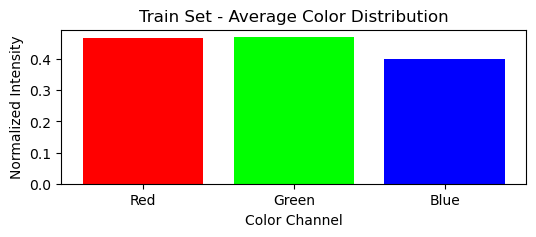


🎨 Test Set - Average RGB Color: [118 118  97]


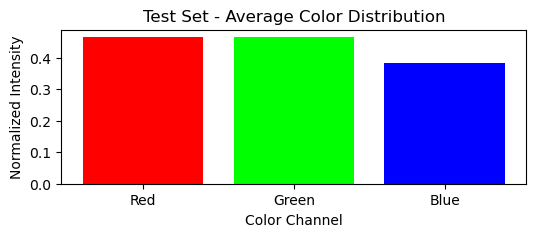


🎨 Validation Set - Average RGB Color: [115 116  96]


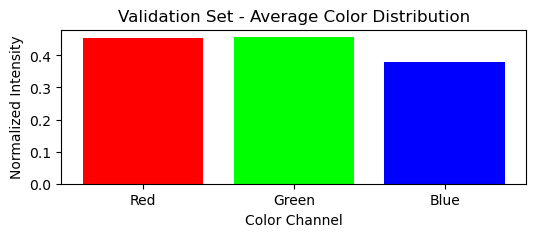

In [24]:
import numpy as np

# Function to compute average color distribution
def analyze_color_distribution(dataset, dataset_name):
    total_pixels = 0
    avg_color = np.zeros(3)  # Store average RGB values

    for images, _ in dataset:  # Iterate over batches
        batch_pixels = np.prod(images.shape[:-1])  # Total pixels in batch
        total_pixels += batch_pixels
        avg_color += images.numpy().reshape(-1, 3).sum(axis=0)  # Sum of RGB values

    avg_color /= total_pixels  # Compute mean RGB values

    # Normalize color values (0-255 scale)
    avg_color_255 = (avg_color * 255).astype(int)

    print(f"\n🎨 {dataset_name} Set - Average RGB Color: {avg_color_255}")

    # Plot color bar
    plt.figure(figsize=(6, 2))
    plt.bar(["Red", "Green", "Blue"], avg_color, color=[(1, 0, 0), (0, 1, 0), (0, 0, 1)])
    plt.xlabel("Color Channel")
    plt.ylabel("Normalized Intensity")
    plt.title(f"{dataset_name} Set - Average Color Distribution")
    plt.show()


# Perform color analysis on train dataset
analyze_color_distribution(train_ds, "Train")
analyze_color_distribution(test_ds,"Test")
analyze_color_distribution(validation_ds,"Validation")

total_pixels → Tracks the total number of pixels processed.

avg_color = np.zeros(3) → Initializes an array to store the sum of Red, Green, and Blue (RGB) values.

np.zeros() is a NumPy function that creates an array filled with zeros.

dataset contains images and their labels.

We ignore the labels (_) since we only care about the image colors.

Images are processed batch-by-batch for efficiency.

np.prod() is a NumPy function that calculates the product of all elements in an array.

The slice [:-1] removes the last dimension from the shape of a NumPy array or TensorFlow tensor.

Example: Understanding shape

arr = np.zeros((32, 256, 256, 3))  # 32 images, each 256x256 with 3 color channels (RGB)
print(arr.shape)

Output:
(32, 256, 256, 3)
This means:

32 → Number of images (batch size)

256x256 → Image dimensions

3 → RGB color channels

shape_excluding_last = arr.shape[:-1]
print(shape_excluding_last)

Output:
(32, 256, 256)
Removes the last dimension (3 for RGB channels)

Leaves only batch size + image dimensions

total_pixels = np.prod(arr.shape[:-1])  
print(total_pixels)

Output:
2097152  # (32 × 256 × 256)
Computes the total number of pixels in all images (without counting color channels).

images.numpy()
Converts the TensorFlow Tensor to a NumPy array.

Used because TensorFlow datasets are in tensor format by default.

Required before using NumPy operations like .reshape() and .sum().

images.numpy().reshape(-1, 3)

reshape(-1, 3) changes the shape of the image batch so that all pixels are flattened into a 2D array.

-1 lets NumPy automatically calculate the number of rows.

Each row represents one pixel with 3 values (RGB channels).

Example Before and After Reshaping

# Assume original shape: (Batch, Height, Width, Channels)
images.shape = (32, 256, 256, 3)  # 32 images of 256x256 pixels with 3 channels

# After reshaping: (-1, 3)
images.numpy().reshape(-1, 3).shape  # (2097152, 3)
2097152 = 32 × 256 × 256 (total number of pixels)

Each row [R, G, B] represents one pixel

.sum(axis=0)

Sums up all RGB values separately.

axis=0 → Sums column-wise, giving three values (total R, G, and B intensities).

Example Calculation

images.numpy().reshape(-1, 3).sum(axis=0)

Output:

[50000000, 42000000, 38000000]  # Total Red, Green, and Blue intensities

50000000 → Total sum of Red values across all pixels

42000000 → Total sum of Green values

38000000 → Total sum of Blue values

Converts a batch of images from (Batch, Height, Width, 3) → (Total Pixels, 3)
Sums up all Red, Green, and Blue pixel values separately
Helps compute average color or analyze color distribution in a dataset

Divides the summed RGB values by the total pixels to get the average intensity of each color channel.

Since TensorFlow processes images in [0,1] format, we scale them back to [0,255].

avg_color * 255

avg_color contains normalized RGB values (between 0 and 1).

Multiplying by 255 scales them to the 0-255 range.

.astype(int)

Converts the floating-point values into integers, as RGB values must be whole numbers.

Displays the average RGB color values for the dataset.

Creates a bar chart to visualize the intensity of Red, Green, and Blue.

The bars are colored red, green, and blue to match their respective channels.

The bar colors are set using RGB tuples:

(1, 0, 0) → Red

(0, 1, 0) → Green

(0, 0, 1) → Blue

COLOR DISTRIBUTION OF IMAGES IS ALMOST THE SAME OVER TRAINING,TESTING,VALIDATION DATA

In [25]:
!pip install opencv-python

DEFINING THE MOBILENETV2 MODEL

In [26]:
'''from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pre-trained MobileNetV2 (excluding top layers)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze base model layers (transfer learning)
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Converts feature maps to a single vector
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
x = Dense(20, activation='softmax')(x)  # 20 classes (softmax for multi-class classification)

# Define the final model
model_1= Model(inputs=base_model.input, outputs=x)

# Compile the model with sparse categorical crossentropy (since labels are integers)
model_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model_1.summary()'''

"from tensorflow import keras\nfrom tensorflow.keras.applications import MobileNetV2\nfrom tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout\nfrom tensorflow.keras.models import Model\n\n# Load pre-trained MobileNetV2 (excluding top layers)\nbase_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))\n\n# Freeze base model layers (transfer learning)\nbase_model.trainable = False\n\n# Add custom classification head\nx = base_model.output\nx = GlobalAveragePooling2D()(x)  # Converts feature maps to a single vector\nx = Dense(128, activation='relu')(x)  # Fully connected layer\nx = Dropout(0.3)(x)  # Dropout to reduce overfitting\nx = Dense(20, activation='softmax')(x)  # 20 classes (softmax for multi-class classification)\n\n# Define the final model\nmodel_1= Model(inputs=base_model.input, outputs=x)\n\n# Compile the model with sparse categorical crossentropy (since labels are integers)\nmodel_1.compile(optimizer='adam', loss='sparse_cat

tensorflow and keras: Used to build deep learning models.

MobileNetV2: A lightweight pre-trained model from ImageNet.

GlobalAveragePooling2D: Reduces feature maps into a single vector for classification.

Dense: Fully connected layers for classification.

Dropout: Prevents overfitting by randomly disabling some neurons during training.

Model: Used to define the final model with custom layers.

📌 Step 2: Load Pre-trained MobileNetV2 (Feature Extractor)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
🔹 What’s happening here?

Loads MobileNetV2 without the top (classification) layer (include_top=False).

Uses ImageNet weights to transfer pre-learned features (avoids training from scratch).

input_shape=(256, 256, 3): Accepts 256×256 color images.

⚡ Why MobileNetV2?

Lightweight and optimized for mobile/embedded devices.

Pre-trained on millions of images, so it already understands general features.

📌 Step 3: Freeze Base Model for Transfer Learning

base_model.trainable = False
🔹 Why?

Freezing means we don’t update the weights of MobileNetV2 during training.

Since MobileNetV2 is already trained on ImageNet, it’s good at recognizing edges, textures, shapes, and objects—which helps in bird classification.

This reduces training time and prevents overfitting.

📌 Later, you can fine-tune it by unfreezing some layers after initial training.

📌 Step 4: Add Custom Classification Head
Now, we add our own layers on top of MobileNetV2 to classify 20 bird species.

x = base_model.output  # Get output of MobileNetV2
x = GlobalAveragePooling2D()(x)  # Converts feature maps to a single vector
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
x = Dense(20, activation='softmax')(x)  # 20 classes (softmax for multi-class classification)
🔹 What’s happening here?
1️⃣ GlobalAveragePooling2D()

Converts large feature maps from MobileNetV2 into a single feature vector per image.

Reduces parameters compared to Flatten(), preventing overfitting.

2️⃣ Dense(128, activation='relu')

A fully connected layer with 128 neurons.

Uses ReLU activation to introduce non-linearity.

3️⃣ Dropout(0.3)

Randomly drops 30% of neurons during training.

Prevents overfitting and helps generalization.

4️⃣ Dense(20, activation='softmax')

20 output neurons for 20 bird species.

softmax converts outputs into probabilities (each class gets a probability between 0 and 1).

📌 Step 5: Define the Final Model

model = Model(inputs=base_model.input, outputs=x)
🔹 What’s happening here?

Combines MobileNetV2 (feature extractor) with our custom classification layers.

Defines a complete model with inputs from MobileNetV2 and outputs from the new dense layers.

📌 Step 6: Compile the Model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
🔹 Breaking it down:

optimizer='adam' → Adaptive learning rate optimization (efficient and widely used).

loss='sparse_categorical_crossentropy' → Used because labels are integers instead of one-hot vectors.

metrics=['accuracy'] → Track classification accuracy during training.

📌 Step 7: Print Model Summary

model.summary()
🔹 Why?

Displays the architecture, number of layers, parameters, and trainable/non-trainable layers.

Helps verify that everything is correctly set up.

🚀 Final Summary
Uses MobileNetV2 as a feature extractor (pre-trained on ImageNet).

Freezes MobileNetV2 layers to retain learned features.

Adds custom dense layers for bird species classification.

Uses GlobalAveragePooling2D for reducing parameters.

Compiles with Adam optimizer and sparse_categorical_crossentropy.

TRAINING WITH THE MOBILENETV2 MODEL

In [27]:
'''# Train the model
history_1 = model_1.fit(
    train_generator,  # Augmented training data
    epochs=10,  # Number of epochs
    validation_data=validation_ds,  # Prefetched validation dataset
    steps_per_epoch=len(train_generator),  # Number of batches in training dataset
    validation_steps=len(validation_ds)  # Number of batches in validation dataset
)'''

'# Train the model\nhistory_1 = model_1.fit(\n    train_generator,  # Augmented training data\n    epochs=10,  # Number of epochs\n    validation_data=validation_ds,  # Prefetched validation dataset\n    steps_per_epoch=len(train_generator),  # Number of batches in training dataset\n    validation_steps=len(validation_ds)  # Number of batches in validation dataset\n)'

 Step 1: Training the Model

history = model.fit(
    train_generator,  # Augmented training data
    epochs=10,  # Number of epochs
    validation_data=validation_ds,  # Prefetched validation dataset
    steps_per_epoch=len(train_generator),  # Number of batches in training dataset
    validation_steps=len(validation_ds)  # Number of batches in validation dataset
)
🔹 What’s happening here?

model.fit() → Starts training the model.

Stores training history (accuracy, loss, validation accuracy, etc.) in history.

📌 Step 2: Understanding the Parameters
1️⃣ train_generator (Training Data)

train_generator  # Augmented training data
Uses ImageDataGenerator to apply real-time image augmentation (rotation, zoom, shift, etc.).

Helps reduce overfitting by making the model see more variations of the same image.

Feeds batches of images on-the-fly instead of loading all images into memory.

2️⃣ epochs=10 (Training Duration)

epochs=10
The model passes through the entire dataset 10 times during training.

More epochs allow the model to learn better but too many epochs can lead to overfitting.

3️⃣ validation_data=validation_ds (Validation Set)

validation_data=validation_ds  # Prefetched validation dataset
validation_ds contains normalized validation images.

Used to evaluate model performance after each epoch without updating weights.

Helps track generalization (how well the model performs on unseen data).

4️⃣ steps_per_epoch=len(train_generator) (Batches Per Epoch)

steps_per_epoch=len(train_generator)
Determines how many batches to process before completing one epoch.

train_generator loads batches dynamically, so we compute:

steps per epoch=Total Training Images/Batch Size

Ensures that all training images are used in each epoch.

5️⃣ validation_steps=len(validation_ds) (Validation Batches)

validation_steps=len(validation_ds)
Determines how many validation batches to process at the end of each epoch.

Ensures that all validation images are evaluated.

📊 What Happens During Training?
📌 For Each Epoch:
1️⃣ Training Phase

train_generator loads and augments images in real-time.

Model makes predictions and updates weights to minimize the loss.

Calculates training accuracy and loss.

2️⃣ Validation Phase

validation_ds provides images for performance evaluation.

Model predictions are compared to actual labels (but weights are NOT updated).

Calculates validation accuracy and loss.

SAVING THE MODEL AND TRAINING HISTORY FOR MOBILENETV2 MODEL

In [28]:
'''import pickle

# Save the training history
with open("training_history_1.pkl", "wb") as file:
    pickle.dump(history_1.history, file)

model_1.save("bird_classification_model_1.h5")  # Saves entire model (architecture + weights)'''

'import pickle\n\n# Save the training history\nwith open("training_history_1.pkl", "wb") as file:\n    pickle.dump(history_1.history, file)\n\nmodel_1.save("bird_classification_model_1.h5")  # Saves entire model (architecture + weights)'

LOADING THE MOBILENETV2 MODEL AND TRAINING HISTORY CHECKING THE TEST ACCURACY

In [29]:
import pickle
from tensorflow.keras.models import load_model

# Load the pre-trained model
model_1 = load_model("bird_classification_model_1.h5")

with open("training_history_1.pkl", "rb") as file:
    history_1 = pickle.load(file)

# Skip training and directly evaluate/predict
test_loss, test_acc = model_1.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 865ms/step - accuracy: 0.9845 - loss: 0.0469
Test Accuracy: 0.99


ACCURACY AND LOSS CURVE COMPARISON BETWEEN TRAINING AND VALIDATION DATA FOR MOBILENETV2 MODEL

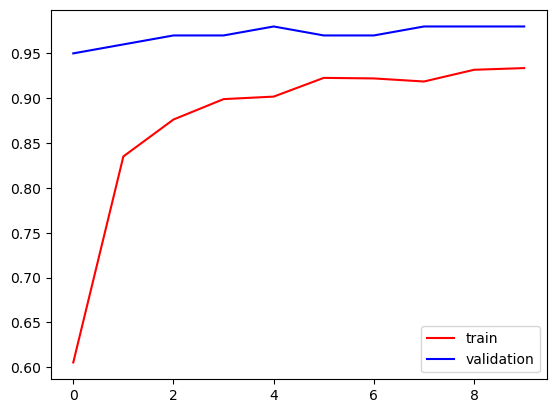

In [30]:
plt.plot(history_1['accuracy'],color='red',label='train')
plt.plot(history_1['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

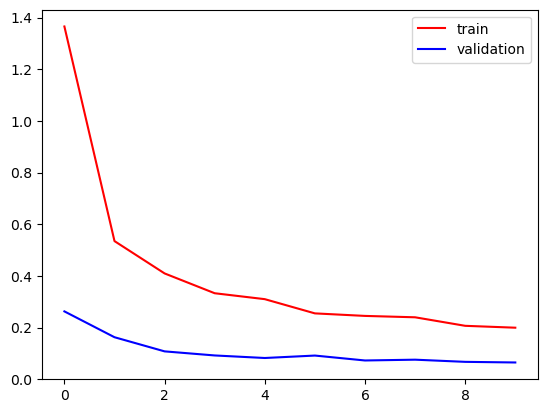

In [31]:
plt.plot(history_1['loss'],color='red',label='train')
plt.plot(history_1['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

PREDICTION USING MOBILENETV2 MODEL

In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load an image (replace 'test_image.jpg' with your image path)
img_path = "Bird Identification/images to predict/8.jpeg"
img = image.load_img(img_path, target_size=(256, 256))  # Resize to model input size
img_array = image.img_to_array(img)  # Convert to NumPy array
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch input
img_array = img_array / 255.0  # Normalize

# Make prediction
predictions = model_1.predict(img_array)
predicted_class = np.argmax(predictions)  # Get class index with highest probability

# Get class labels from training generator
class_labels = list(train_generator.class_indices.keys())
print(f"Predicted Class: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: ALEXANDRINE PARAKEET


 Step 1: Import Required Libraries

import numpy as np
from tensorflow.keras.preprocessing import image
numpy → Used for array manipulations.

image → Helps load and preprocess images before feeding them into the model.

📌 Step 2: Load and Preprocess the Image

img_path = "Bird Identification/images to predict/7.jpeg"
img = image.load_img(img_path, target_size=(256, 256))  # Resize to model input size
Loads the image from the specified path.

Resizes the image to (256, 256), which is required by the model.

📌 Step 3: Convert Image to NumPy Array

img_array = image.img_to_array(img)  # Convert to NumPy array
Converts the image into a NumPy array so that it can be processed by TensorFlow.

Shape after conversion: (256, 256, 3) (height, width, RGB channels).

📌 Step 4: Add a Batch Dimension

img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch input
Machine learning models expect batch inputs, even for a single image.

Expanding dimensions converts shape from (256, 256, 3) to (1, 256, 256, 3).

Now the image is treated as a batch of 1 image.

📌 Step 5: Normalize the Image

img_array = img_array / 255.0  # Normalize
Divides pixel values by 255 to scale them between [0, 1] (same as training data).

Normalization improves model stability and ensures consistency with training images.

📌 Step 6: Make Prediction

predictions = model.predict(img_array)
Feeds the preprocessed image into the trained model.

The model outputs probabilities for each class (20 bird species).

Example output:

predictions = [0.01, 0.03, 0.85, 0.02, 0.09]  # Example (for 5 classes)
Here, the highest probability (0.85) corresponds to the 3rd class (index 2).

📌 Step 7: Get the Predicted Class

predicted_class = np.argmax(predictions)  # Get class index with highest probability
np.argmax() finds the index of the highest probability in predictions.

Example:

predictions = [0.01, 0.03, 0.85, 0.02, 0.09]
np.argmax(predictions)  # Output: 2 (3rd class)

📌 Step 8: Map Index to Class Name

class_labels = list(train_generator.class_indices.keys())
print(f"Predicted Class: {class_labels[predicted_class]}")
train_generator.class_indices is a dictionary mapping bird species to index values:

{'sparrow': 0, 'eagle': 1, 'parrot': 2, 'crow': 3, 'pigeon': 4}
Maps the predicted index to the actual class name.

DEFINING AND TRAINING WITH THE CNN MODEL

In [33]:
'''import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest')

# Rescale Validation & Test Data
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Data
train_generator = train_datagen.flow_from_directory('Bird Identification/train', target_size=(256, 256), batch_size=64, class_mode='sparse')
validation_generator = val_datagen.flow_from_directory('Bird Identification/valid', target_size=(256, 256), batch_size=64, class_mode='sparse')
test_generator = test_datagen.flow_from_directory('Bird Identification/test', target_size=(256, 256), batch_size=64, class_mode='sparse')

# Define CNN Model
model_2 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(20, activation='softmax')
])

# Compile Model
model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
checkpoint = ModelCheckpoint('bird_classification_model_2.h5', monitor='val_loss', save_best_only=True)

# Train Model
history_2 = model_2.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)'''

"import tensorflow as tf\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization\nfrom tensorflow.keras.preprocessing.image import ImageDataGenerator\nfrom tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau\n\n# Data Augmentation for Training Data\ntrain_datagen = ImageDataGenerator(\n    rescale=1./255,\n    rotation_range=40,\n    width_shift_range=0.2,\n    height_shift_range=0.2,\n    shear_range=0.2,\n    zoom_range=0.3,\n    horizontal_flip=True,\n    fill_mode='nearest')\n\n# Rescale Validation & Test Data\nval_datagen = ImageDataGenerator(rescale=1./255)\ntest_datagen = ImageDataGenerator(rescale=1./255)\n\n# Load Data\ntrain_generator = train_datagen.flow_from_directory('Bird Identification/train', target_size=(256, 256), batch_size=64, class_mode='sparse')\nvalidation_generator = val_datagen.flow_from_directory('Bird Identification/valid', target_siz

1. Import Required Libraries

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

TensorFlow/Keras: Used to build and train the CNN model.

Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization:
These are CNN layers to extract image features.

ImageDataGenerator: Helps in data preprocessing & augmentation.

Callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau): Used to improve training stability.

2. Data Preprocessing & Augmentation

Data Augmentation for Training Data

train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values (0 to 1)
    rotation_range=40,  # Rotate images randomly up to 40 degrees
    width_shift_range=0.2,  # Shift image horizontally
    height_shift_range=0.2,  # Shift image vertically
    shear_range=0.2,  # Shear transformation
    zoom_range=0.3,  # Zoom in/out on images
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill missing pixels using nearest neighbors
)

Why Augment?  Helps prevent overfitting by creating new variations of images.

Rescaling for Validation & Test Data

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
Only rescale is applied (no augmentation) because validation & test sets should remain unchanged.

3. Load the Dataset

train_generator = train_datagen.flow_from_directory(
    'Bird Identification/train', 
    target_size=(256, 256), 
    batch_size=64, 
    class_mode='sparse'
)

Loads images from the 'train' directory.

Resizes all images to (256, 256).

Batch size = 64 (number of images processed in one step).

class_mode='sparse': Since labels are encoded as integers.

Similarly, for validation and test sets:

validation_generator = val_datagen.flow_from_directory('Bird Identification/valid', target_size=(256, 256), batch_size=64, class_mode='sparse')
test_generator = test_datagen.flow_from_directory('Bird Identification/test', target_size=(256, 256), batch_size=64, class_mode='sparse')

4. Define the CNN Model

model_2 = Sequential([
    # First Conv Block
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Second Conv Block
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Third Conv Block
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Fourth Conv Block
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(20, activation='softmax')  # 20 Output Classes (Softmax for multi-class classification)
])

Layer Breakdown:

4 Convolutional Blocks (Conv2D + BatchNormalization + MaxPooling2D)

Extracts important features from the images.

Batch Normalization speeds up training.

Flatten Layer

Converts 2D feature maps into a 1D vector for the fully connected layers.

Fully Connected Layers

Dense(512, activation='relu') → Learning complex patterns.

Dropout Layers → Prevent overfitting.

Output Layer (20 classes, softmax activation).

5. Compile the Model

model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

Adam Optimizer (learning_rate=5e-5 or 0.00005) → Small learning rate for stable training.

Sparse Categorical Crossentropy → Suitable for integer-encoded labels.

Accuracy as the metric → Measures model performance.

6. Define Callbacks

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Early Stopping: Stops training if validation loss doesn’t improve for 10 epochs.

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)

Reduce Learning Rate:

If validation loss stops improving for 5 epochs, the learning rate is reduced by 50%.

Prevents the model from getting stuck at a poor solution.

checkpoint = ModelCheckpoint('bird_classification_model_2.h5', monitor='val_loss', save_best_only=True)

Model Checkpoint: Saves the best model based on lowest validation loss.

7. Train the Model

history_2 = model_2.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)

Training for 30 epochs (unless early stopping occurs).

Uses training & validation generators.

Uses callbacks:

early_stopping → Stops training early if no improvement.

checkpoint → Saves the best model.

reduce_lr → Adjusts learning rate when needed.

Steps per epoch:

steps_per_epoch=len(train_generator): How many batches per epoch.

validation_steps=len(validation_generator): Validation set batch count.

SAVING THE CNN MODEL AND TRAINING HISTORY

In [34]:
'''import pickle

# Save the training history
with open("training_history_2.pkl", "wb") as file:
    pickle.dump(history_2.history, file)

model_2.save("bird_classification_model_2.h5")'''

'import pickle\n\n# Save the training history\nwith open("training_history_2.pkl", "wb") as file:\n    pickle.dump(history_2.history, file)\n\nmodel_2.save("bird_classification_model_2.h5")'

LOADING THE CNN MODEL AND TRAINING HISTORY CHECKING THE TEST ACCURACY

In [35]:
import pickle
from tensorflow.keras.models import load_model

# Load the pre-trained model
model_2 = load_model("bird_classification_model_2.h5")

with open("training_history_2.pkl", "rb") as file:
    history_2 = pickle.load(file)

# Skip training and directly evaluate/predict
test_loss, test_acc = model_2.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step - accuracy: 0.8030 - loss: 0.7623
Test Accuracy: 0.82


ACCURACY AND LOSS CURVE COMPARISON BETWEEN TRAINING AND VALIDATION DATA FOR CNN MODEL

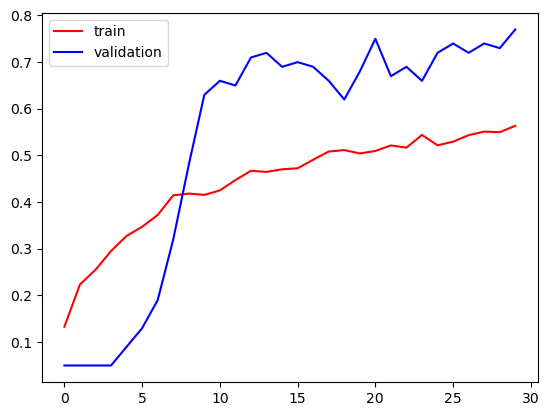

In [36]:
plt.plot(history_2['accuracy'],color='red',label='train')
plt.plot(history_2['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

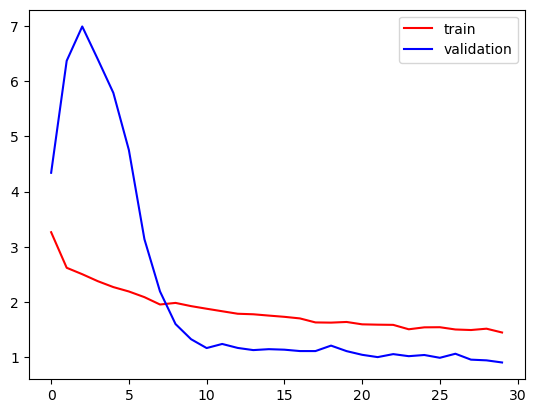

In [37]:
plt.plot(history_2['loss'],color='red',label='train')
plt.plot(history_2['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

PREDICTION USING CNN MODEL

In [38]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load an image (replace 'test_image.jpg' with your image path)
img_path = "Bird Identification/images to predict/1.jpg"
img = image.load_img(img_path, target_size=(256, 256))  # Resize to model input size
img_array = image.img_to_array(img)  # Convert to NumPy array
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch input
img_array = img_array / 255.0  # Normalize

# Make prediction
predictions = model_2.predict(img_array)
predicted_class = np.argmax(predictions)  # Get class index with highest probability

# Get class labels from training generator
class_labels = list(train_generator.class_indices.keys())
print(f"Predicted Class: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
Predicted Class: AFRICAN CROWNED CRANE


In [39]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load an image (replace 'test_image.jpg' with your image path)
img_path = "Bird Identification/images to predict/8.jpeg"
img = image.load_img(img_path, target_size=(256, 256))  # Resize to model input size
img_array = image.img_to_array(img)  # Convert to NumPy array
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch input
img_array = img_array / 255.0  # Normalize

# Make prediction
predictions = model_2.predict(img_array)
predicted_class = np.argmax(predictions)  # Get class index with highest probability

# Get class labels from training generator
class_labels = list(train_generator.class_indices.keys())
print(f"Predicted Class: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted Class: AMERICAN GOLDFINCH
